In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the data

In [9]:
data = pd.read_csv('P53.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7467 entries, 0 to 7466
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   mutant            7467 non-null   object 
 1   mutated_sequence  7467 non-null   object 
 2   DMS_score         7467 non-null   float64
 3   DMS_score_bin     7467 non-null   int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 233.5+ KB


In [10]:
data.head()

,mutant,mutated_sequence,DMS_score,DMS_score_bin
0,M1A,AEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,-0.788753,0
1,M1C,CEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,-1.969077,0
2,M1Y,YEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,-1.333315,0
3,M1W,WEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,-2.219256,0
4,M1V,VEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,-0.669727,0


### Data Structure

The column "mutant" provides a summary of each variant in three components: the first letter reflects the wild-type state at the mutated position, the number reflects the position at which the variant was mutated, and the third letter reflects the mutant state at that position. 

"mutated_sequence" is full the amino acid sequence of the variant (wild-type, save the mutant position). 

DMS_score is the log-normalized functional score of the mutant.

"DMS_score_bin" is the binarized version of DMS_score, where 1 indicates a functional mutant and 0 indicates a non-functional mutant.

In [11]:
data["DMS_score"].describe()

count    7467.000000
mean        0.046731
std         0.978440
min        -3.943922
25%        -0.499698
50%         0.350252
75%         0.738673
max         2.533067
Name: DMS_score, dtype: float64

This single DMS dataset is complete. We have 7467 variants to work with, reflecting the 19 alternative amino acid states at all 393 positions in the sequence.

## Data Exploration

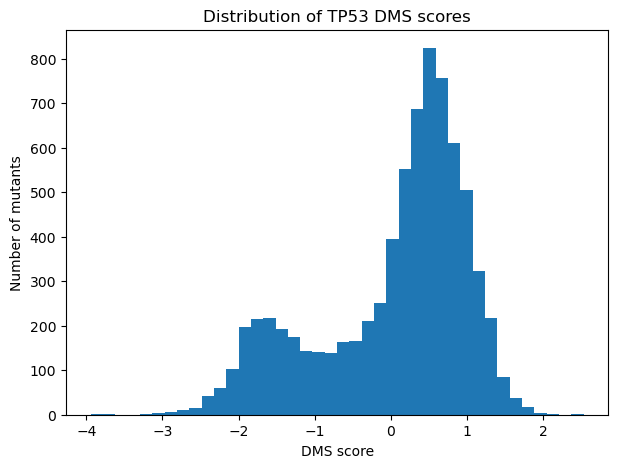

In [12]:
plt.figure(figsize=(7, 5))
plt.hist(data["DMS_score"], bins=40)
plt.xlabel("DMS score")
plt.ylabel("Number of mutants")
plt.title("Distribution of TP53 DMS scores")
plt.show()

The above plot shows us the distribution of DMS scores of the mutants in our data. They are not evenly distributed and instead occupy a bimodal distributio.. Many mutants have scores near 0 and 1, which suggests that many of the mutations have neutral to mildly beneficial effects. There is a second significant group centered between -1 and -2, which tells us that a subset of the mutations are deleterious. 

This spread supports predicting on the binary DMS_score_bin. While scores are continuous, there are two clear modees and a meaningful boundary betwen the categories. Further, the medically-relevant phenotypic value here is Loss-of-Function, where the protein is no longer able to suppress tumor growth. As such, predicting binary function is more clinically relevant.

In [13]:
# We can extract information about the position of the mutation. 
# The "mutant" column has format X123Y, where X is the wild-type amino acid, 
# 123 is the position of the mutation, and Y is the mutant amino acid.

data["position"] = data["mutant"].str.extract(r"(\d+)").astype(int)
data["wt_aa"] = data["mutant"].str[0]
data["mut_aa"] = data["mutant"].str[-1]

data.head()

,mutant,mutated_sequence,DMS_score,DMS_score_bin,position,wt_aa,mut_aa
0,M1A,AEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,-0.788753,0,1,M,A
1,M1C,CEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,-1.969077,0,1,M,C
2,M1Y,YEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,-1.333315,0,1,M,Y
3,M1W,WEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,-2.219256,0,1,M,W
4,M1V,VEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,-0.669727,0,1,M,V


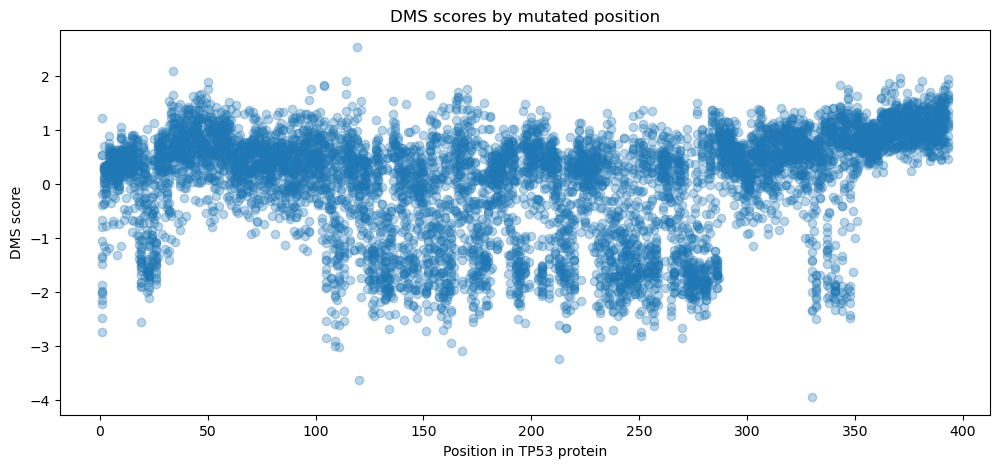

In [14]:
plt.figure(figsize=(12, 5))
plt.scatter(data["position"], data["DMS_score"], alpha=0.3)

plt.xlabel("Position in TP53 protein")
plt.ylabel("DMS score")
plt.title("DMS scores by mutated position")
plt.show()

This scatterplot shows the DMS score for each mutation across positions in the TP53 protein. Each point represents one variant, wherein a single position along the protein has been mutated to a single alternative amino acid. As such, there are 19 variants per position. 

This plot tells us that the mutation effects are not evenly distributed across TP53's amino acid sequence. Some regions, such as the C terminus (near the end of the protein), are more tolerant of mutations and show a high concentration of neutral to beneficial mutations, and few if any negative scores. Regions such as around positions 100-300 show many low DMS scores, which indicates that mutations in these regions is very detrimental to the function of the protein.

## Data Processing

In [15]:
# define the Atchley factor dictionary, with a value for each AA corresponding to a vector of the 5 factors
atchley = {
    'A': [-0.591, -1.302, -0.733,  1.570, -0.146],
    'C': [-1.343,  0.465, -0.862, -1.020, -0.255],
    'D': [ 1.050,  0.302, -3.656, -0.259, -3.242],
    'E': [ 1.357, -1.453,  1.477,  0.113, -0.837],
    'F': [-1.006, -0.590,  1.891, -0.397,  0.412],
    'G': [-0.384,  1.652,  1.330,  1.045,  2.064],
    'H': [ 0.336, -0.417, -1.673, -1.474, -0.078],
    'I': [-1.239, -0.547,  2.131,  0.393,  0.816],
    'K': [ 1.831, -0.561,  0.533, -0.277,  1.648],
    'L': [-1.019, -0.987, -1.505,  1.266, -0.912],
    'M': [-0.663, -1.524,  2.219, -1.005,  1.212],
    'N': [ 0.945,  0.828,  1.299, -0.169,  0.933],
    'P': [ 0.189,  2.081, -1.628,  0.421, -1.392],
    'Q': [ 0.931, -0.179, -3.005, -0.503, -1.853],
    'R': [ 1.538, -0.055,  1.502,  0.440,  2.897],
    'S': [-0.228,  1.399, -4.760,  0.670, -2.647],
    'T': [-0.032,  0.326,  2.213,  0.908,  1.313],
    'V': [-1.337, -0.279, -0.544,  1.242, -1.262],
    'W': [-0.595,  0.009,  0.672, -2.128, -0.184],
    'Y': [ 0.260,  0.830,  3.097, -0.838,  1.512]
}

In [17]:
# data extraction from column 'mutant'
## atchley factor conversion for mutant and wildtype followed by subtraction
## position encoded as a sixth feature to avoid having extremely sparse samples
#### ex. M1A -> wt atchley for M, mut atchley for A, position = 1

def encode_mutant(mutant_str):
    wt_aa = mutant_str[0]
    mut_aa = mutant_str[-1]
    position = int(mutant_str[1:-1])
    delta = np.array(atchley[mut_aa]) - np.array(atchley[wt_aa])
    return np.append(delta, position)


# convert data and collate rows (1 row = 1 mutant)
X = np.vstack([encode_mutant(m) for m in data['mutant']])
